# $$ \textbf{Sinais e Sistemas Dinâmicos - Unidade 2}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [2]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 3. Análise de Sinais Periódicos


### 3.1 Introdução

Este seção é inteiramente dedicada ao estudo de sinais periódicos a tempo contínuo e a tempo discreto. Uma entidade matemática absolutamente singular denominada **Série de Fourier** será apresentada e analisada com bastante detalhe. 

Em linhas gerais, *podemos dizer que qualquer sinal periódico definido no domínio do tempo, em $\mathbb{R}$ ou $\mathbb{Z}$, pode ser decomposto em um número infinito de componentes que compõem o seu espectro de frequências*. 

A luz, por exemplo, é um sinal que tem um espectro denominado espectro eletromagnético bem conhecido. A série de Fourier permite decompor e aproximar um sinal através de uma combinação linear das suas componentes fundamentais. Como consequência, permite também calcular a sua potência média através de um resultado importante e famoso denominado **Teorema de Parseval**. 

O estudo começa com a formulação e resolução de um **problema de erro quadrático mínimo**, cuja solução se torna uma ferramenta essencial para o estudo de sinais e sistemas.

### 3.2 Representação de Sinais
Considere um conjunto de vetores $v_i \in \mathbb{R}^n$ para todo $i=1, \cdots, m$ em que $m \leq n$. Uma pergunta importante que deve ser respondida é: dado um vetor $y \in \mathbb{R}^n$, existem constantes $\alpha_i \in \mathbb{R}, i=1,2, \cdots, m$ não todas nulas de tal forma que $y$ seja expresso como $y=\sum_{i=1}^m \alpha_i v_i$ ? A resposta a esta pergunta, que pode ou não ser afirmativa, permitiu o desenvolvimento de importantes conceitos em diversas áreas da matemática, tais como os de combinação linear e de base em um espaço vetorial. Como $y$ é um vetor arbitrário com $n$ componentes, a resposta, para ser afirmativa, exige que $m=n$ e que os vetores sejam **linearmente independentes**, o que quer dizer que a matriz quadrada $V=\left[\begin{array}{lll}v_1 & \cdots & v_n\end{array}\right] \in \mathbb{R}^{n \times n}$ deve ser não singular $\operatorname{det}(V) \neq 0$. 

No estudo de sinais a tempo contínuo $g(t)$ com domínio $\mathbb{R}$ e imagem $\mathbb{C}$, desejamos determinar um conjunto de $m$ (que pode ser infinito) sinais $f_i(t), i=$ $1,2, \cdots, m$ com os mesmos domínios e imagens, de tal forma que existam escalares $\alpha_i \in \mathbb{C}, \forall i=1,2, \cdots, m$ capazes de garantir a igualdade
$$
g(t)=\sum_{i=1}^m \alpha_i f_i(t), \forall t \in \mathbb{R}
$$
Neste sentido, formulamos o seguinte problema de otimização denominado **erro quadrático mínimo**

$$
\min _{\alpha_1, \alpha_2, \cdots, \alpha_m}\left\|g-\sum_{i=1}^m \alpha_i f_i\right\|^2
$$
em que $\|\cdot\|$ é a norma induzida pelo produto interno. 

A solução ótima deste problema remete ao Teorema de Pitágoras, pois exige ortogonalidade. De fato, para cada conjunto de parâmetros $\alpha_1, \alpha_2, \cdots, \alpha_m$ escolhidos definimos o **sinal de erro** como sendo
$$
\epsilon(t)=g(t)-\sum_{i=1}^m \alpha_i f_i(t), \quad \forall t \in \mathbb{R}
$$

e para resolver o problema de otimização devemos determinar os parâmetros, que são as nossas variáveis de decisão, de tal forma que a norma do erro seja a menor possível (idealmente, zero). 

A Figura 3.1 ilustra o que ocorre com as funções transformadas em vetores para que a ilustração geométrica seja possível. A combinação ótima de $f_1$ e $f_2$ deve gerar um ponto que é exatamente a projeção ortogonal do ponto $O$ no plano definido por $f_1$ e $f_2$, pois essa situação define a menor distância entre o ponto $O$ e qualquer ponto do referido plano. Dito de outra forma, o erro deve ser ortogonal a $f_1$ e a $f_2$.

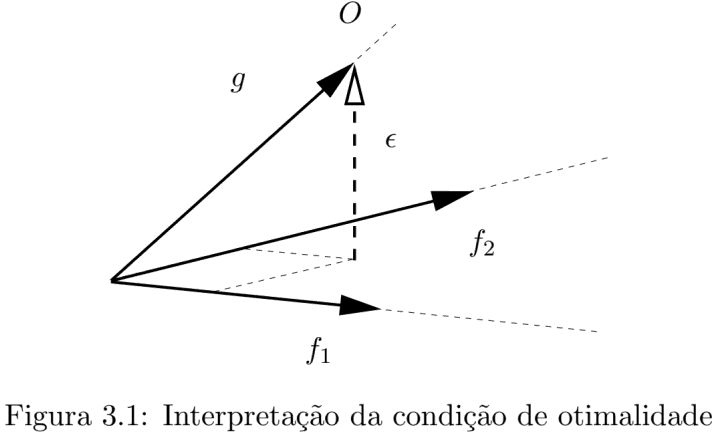

Retomando o problema do erro quadrático mínimo, sua condição de otimalidade se expressa na forma $\left\langle\epsilon, f_n\right\rangle=0$ para todo $n=1,2, \cdots, m$, o que leva ao sistema de equações lineares
$$
\left\langle g, f_n\right\rangle-\sum_{i=1}^m \alpha_i\left\langle f_i, f_n\right\rangle=0, \quad n=1,2, \cdots, m
$$
Trata-se de um sistema com $m$ equações e $m$ incógnitas que depende de alguma condição para que possa se resolvido e, eventualmente, tenha solução única. Isto ocorre sempre que os sinais que constituem a base $f_i, i=1,2, \cdots, m$ forem ortogonais entre si. 

Na equação acima este fato que se traduz por $\left\langle f_i, f_n\right\rangle=0$ para todo $i \neq n=1,2, \cdots, m$, as equações se desacoplam e fornecem imediatamente a solução procurada

$$
\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m
$$
Tendo conhecimento da solução ótima, podemos avaliar o valor mínimo da norma ao quadrado do erro correspondente, que é dado por
$$
\begin{aligned}
\|\epsilon\|^2 & =\left\langle\epsilon, g-\sum_{i=1}^m \alpha_i f_i\right\rangle \\
& =\left\langle g-\sum_{i=1}^m \alpha_i f_i, g\right\rangle \\
& =\|g\|^2-\sum_{i=1}^m\left|\alpha_i\right|^2\left\|f_i\right\|^2
\end{aligned}
$$
onde utilizamos a relação que decorre de $\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m $ e permite determinar o conjugado do parâmetro ótimo
$$
\begin{aligned}
\alpha_i^* & =\frac{\left\langle g, f_i\right\rangle^*}{\left\langle f_i, f_i\right\rangle} \\
& =\frac{\left\langle f_i, g\right\rangle}{\left\|f_i\right\|^2}
\end{aligned}
$$
O ponto central é como escolher um conjunto de funções ortogonais de tal forma que para sinais de uma certa classe sempre existam parâmetros $\alpha_i \in \mathbb{C}, i=$ $1,2, \cdots, m$ que tornem o erro nulo. 

Como veremos em seguida, esta talvez seja a maior contribuição de Fourier ao propor uma base para os sinais periódicos a tempo contínuo ou a tempo discreto que exibe esta importante propriedade.

**Exemplo 3.1** Não é difícil construir uma base ortogonal de sinais. Uma possibilidade é fazer $f_i(t)=v\left(t-\tau_i\right)-v\left(t-\tau_{i+1}\right)$, em que $\tau_{i+1}-\tau_i=d>0$ com $i \in \mathbb{Z}$. O $i$-ésimo sinal é igual a 1 para todo $\tau_i \leq t<\tau_{i+1}$ e zero para todo $t \in \mathbb{R}$ fora deste intervalo. Portanto, todos são ortogonais entre si. Ademais, é fácil determinar $\left\|f_i\right\|^2=\tau_{i+1}-\tau_i$ e que para um sinal $g(t)$ dado
$$
\alpha_i=\frac{1}{\tau_{i+1}-\tau_i} \int_{\tau_i}^{\tau_{i+1}} g(t) d t
$$
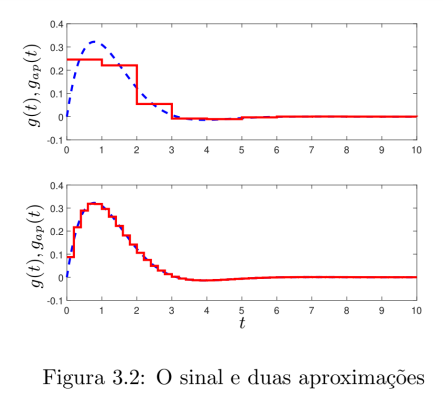

A Figura 3.2 ilustra este resultado aplicado ao sinal $g(t)=e^{-t} \operatorname{sen}(t) v(t)$. Na sua parte superior aparece o sinal $g(t)$ e a função aproximada $g_{a p}(t)=\sum_{i=0}^{\infty} \alpha_i f_i(t) \operatorname{com} d=1[\mathrm{~s}]$. Nota-se uma grande diferença entre as duas funções, o que indica um erro quadrático mínimo bastante elevado. Na parte inferior mostramos o mesmo sinal e sua aproximação, mas com $d=0.2$. A redução do erro quadrático mínimo é visível. Para $d \rightarrow 0^{+}$ele tende a zero.

### 3.3 Sinais a Tempo Contínuo
Consideramos, exclusivamente, sinais periódicos com período $T_0>0$ a tempo contínuo com domínio em $\mathbb{R}$ e com imagem $\mathbb{C}$. Em várias situações, que são as mais importantes em aplicações práticas, a imagem do sinal de interesse será o conjunto dos números reais $\mathbb{R}$. Como já sabemos, um sinal $g(t)$ é periódico se existir $T_0>0$ tal que $t+T_0 \in \mathbb{R}$ para todo $t \in \mathbb{R}$ e
$$
g(t)=g\left(t+T_0\right), \forall t \in \mathbb{R}
$$
o menor $T_0$ que satisfaz estas condições é o seu período fundamental. 

Para esta classe de sinais, vamos restringir o seu domínio a $t \in\left[0, T_0\right] \subset \mathbb{R}$, pois toda propriedade que vale para um período vale também para todos os demais. 

O resultado central, neste caso, diz respeito à existência de um conjunto infinito de sinais ortogonais, a saber
$$
f_i(t)=e^{j \omega_i t}, \omega_i=\frac{2 \pi}{T_0} i
$$

para todo $i \in \mathbb{Z}$. As frequências $\omega_i$, expressas em $[\mathrm{rad} / \mathrm{s}]$, são denominadas **harmônicas**, ou seja, $\omega_1$ é a **primeira harmônica**, $\omega_2$ a **segunda harmônica** e assim por diante. 

Ao restringirmos nossa atenção a apenas um período, podemos verificar sem dificuldades que, de fato, todos estes sinais são ortogonais entre si. 

Adaptando a *definiçāo de produto escalar de sinais com domínio em $t \in\left[0, T_0\right] \mathrm{e}$ imagem $\mathbb{C}$*, temos imediatamente que
$$
\left\langle f_i, f_n\right\rangle=\int_0^{T_0} e^{j\left(\omega_i-\omega_n\right) t} d t=\left\{\begin{array}{cc}
T_0, & i=n \\
0, & i \neq n
\end{array}\right.
$$
Para este conjunto de sinais, com $\alpha_i=\frac{\left\langle g, f_i\right\rangle}{\left\langle f_i, f_i\right\rangle}, i=1,2, \cdots, m$, podemos calcular os coeficientes que correspondem ao erro quadrático mínimo, ou seja,
$$
\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}
$$
e concluir que, se o erro quadrático mínimo for nulo, então a seguinte igualdade
$$
g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}
$$
é válida. Isto decorre de $g(t)$ ser um sinal periódico, com período $T_0>0$. Como o erro é periódico com período $T_0>0$, se ele for nulo em um período, então ele será nulo em todos os demais períodos, ou seja, para todo $t \in \mathbb{R}$. O próximo lema torna explícita as condições para que a última igualdade ocorra.

**Lema 3.1** Os sinais $\left\{f_i\right\}_{i \in \mathbb{Z}}$ definidos em $f_i(t)=e^{j \omega_i t}, \omega_i=\frac{2 \pi}{T_0} i$ formam um **conjunto completo**, isto é, o erro quadrático mínimo
$$
\|\epsilon\|^2=\int_0^{T_0}|\epsilon(t)|^2 d t
$$
é nulo.

A prova deste resultado vai além do escopo deste curso e, portanto, será omitida. É preciso ficar claro que isto não implica que $\epsilon(t)=0$ para todo $t \in\left[0, T_0\right)$. De fato, pode ocorrer que $\epsilon(t) \neq 0$ em pontos isolados e a integral acima se mantenha nula. Isto ocorre nos pontos onde o sinal $g(t)$ é descontínuo, o que é muito frequente, sobretudo nos pontos extremos dos intervalos de tempo $t \in\left[k T_0,(k+1) T_0\right)$ $\operatorname{com} k \in \mathbb{Z}$ que se sucedem indefinidamente. 

Este e outros importantes aspectos serão ilustrados através dos exemplos que passamos a discutir em seguida. 

<p style="color: blue">A expressão
$$
g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}
$$ 
com $\alpha_i, i \in \mathbb{Z}$ dados em 
$$
\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}
$$
é denominada Série de Fourier do sinal $g(t)$.</p>


**Exemplo 3.2** Vamos determinar a série de Fourier para um sinal periódico cujo primeiro período é dado por
$$
g(t)=\left\{\begin{array}{ccc}
1 & , & |t| \leq a / 2 \\
0 & , & a / 2<|t| \leq T_0 / 2
\end{array}\right.
$$
a relaçāo $r=a / T_0$ é o seu **fator de ocupaçāo**. Trata-se de um sinal conhecido como **trem de pulsos**. 

Com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$, determinamos os coeficientes da série, sendo que mudamos os limites de integração para facilitar os cálculos. O resultado permanece inalterado pois mantém-se a integração em um período completo. Obtemos
$$
\begin{aligned}
\alpha_i & =\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t) e^{-j \omega_i t} d t \\
& =\frac{1}{T_0} \int_{-a / 2}^{a / 2} e^{-j \omega_i t} d t \\
& =\frac{a}{T_0} \operatorname{sinc}\left(\omega_i a / 2\right)
\end{aligned}
$$
para todo $i \in \mathbb{Z}$. Como $\omega_i a / 2=\pi\left(a / T_0\right) i$, cada coeficiente $\alpha_i$ depende apenas do fator de ocupação $r$. 


A Figura 3.3 mostra três períodos do sinal $g(t) \operatorname{com} T_0=1[\mathrm{~s}], a=0,25$ e as aproximações obtidas pelo truncamento da série de Fourier $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t} \mathrm{com}$ $m \in\{2,5,20,50\}$. 

In [8]:
#from sympy import fourier_series, pi, plot
from sympy.abc import t
g = sym.Piecewise((1, (-0.25 <= t) & (t <=0.25)), (0, True))
s = fourier_series(g, (t, -0.5, 0.5))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 5)
s3 = s.truncate(n = 20)
s4 = s.truncate(n = 50)

g = sym.Piecewise((1, (-0.25 <= t) & (t <=0.25)), (1, (-1.25 <= t) & (t <=- 0.75)), 
                  (1, (0.75 <= t) & (t <=1.25)), (1, (1.75 <= t) & (t <=2.25)), 
                  (1, (-2.25 <= t) & (t <=-1.75)), (0, True))

p1 = sym.plot(g, s1, (t, -2, 2), title='Figura 3.3 - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -2, 2), title='Figura 3.3 - $m=5$', show=False, legend=True)
p3 = sym.plot(g, s3, (t, -2, 2), title='Figura 3.3 - $m=20$', show=False, legend=True)
p4 = sym.plot(g, s4, (t, -2, 2), title='Figura 3.3 - $m=50$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p3[0].line_color = 'b'
p3[0].label = '$g(t)$'
p4[0].line_color = 'b'
p4[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=5'
p3[1].line_color = 'r'
p3[1].label = 'm=20'
p4[1].line_color = 'r'
p4[1].label = 'm=50'


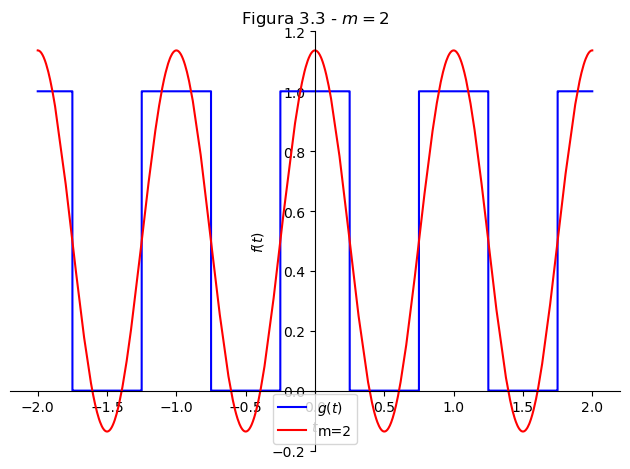

In [9]:
p1.show()

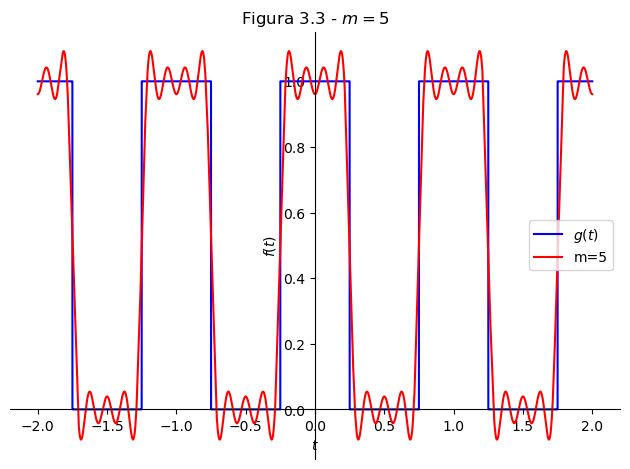

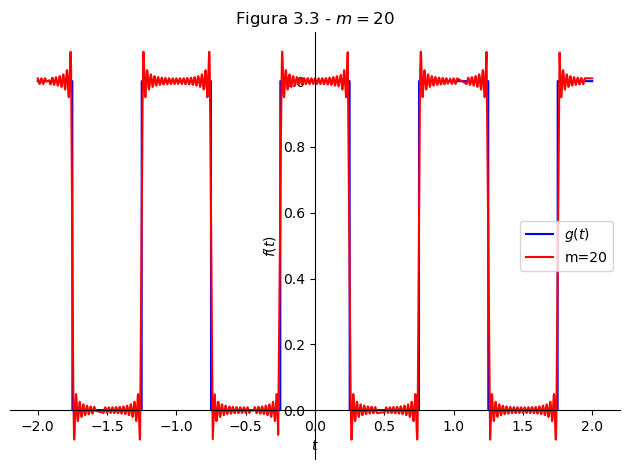

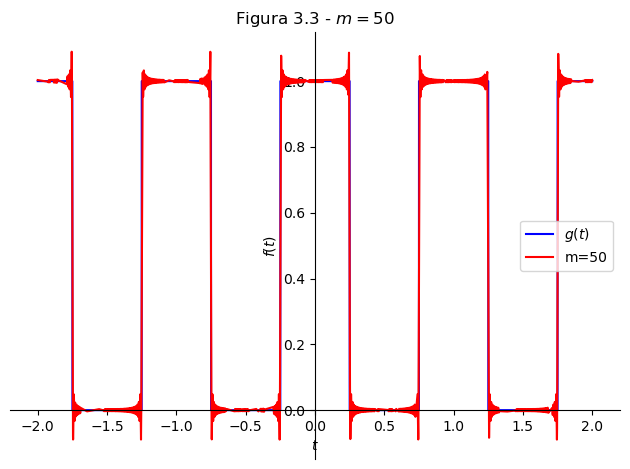

(None, None, None)

In [10]:
p2.show(), p3.show(), p4.show()

**Exemplo 3.3** Um caso interessante é o sinal periódico denominado **trem de impulsos**, definido por 
$$g(t)=\sum_{k=-\infty}^{\infty} \delta\left(t-k T_0\right),$$ que é muito parecido com o sinal do exemplo anterior, mas com os pulsos sendo substituídos por impulsos unitários. 

Com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$ determinamos os coeficientes da série de Fourier como sendo
$$
\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} \delta(t) e^{-j \omega_i t} d t=\frac{1}{T_0}
$$
para todo $i \in \mathbb{Z}$ e, assim, estabelece-se a igualdade
$$
\sum_{k=-\infty}^{\infty} \delta\left(t-k T_0\right)=\frac{1}{T_0} \sum_{i=-\infty}^{\infty} e^{j\left(2 \pi / T_0\right) i t}, \forall t \in \mathbb{R}
$$

Esta relação é muito útil em diversas situações e deve ser entendida de uma maneira peculiar. Para todo $t \in \mathbb{R}$ a série de Fourier assume valores reais. Ademais, para todo $t \neq k T_0, \forall k \in \mathbb{Z}$, a série converge para zero. Nos instantes $t=k T_0, \forall k \in \mathbb{Z}$, a série de Fourier diverge para $+\infty$ com a forma de um impulso, tendo em vista que
$$
\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} \sum_{i=-\infty}^{\infty} e^{j\left(2 \pi / T_0\right) i t} d t=\sum_{i=-\infty}^{\infty} \operatorname{sinc}(\pi i)=1
$$

ou seja, a integral no interior do primeiro período é igual a um. A divergência da série de Fourier, nesses instantes de tempo, não ocorre de qualquer maneira, pois sua integral, em cada período, se mantém constante.

**Exemplo 3.4** Vamos agora obter a série de Fourier de um sinal denominado **dente de serra**, cujo primeiro período é definido por $g(t)=a t,|t| \leq T_0 / 2$, em que $a \in$ $\mathbb{R}$. Novamente com $\alpha_i=\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j \omega_i t} d t, i \in \mathbb{Z}$, determinamos os coeficientes da série de Fourier, que são dados por $\alpha_0=0$ e
$$
\begin{aligned}
\alpha_i & =\frac{a}{T_0} \int_{-T_0 / 2}^{T_0 / 2} t e^{-j \omega_i t} d t \\
& =j \frac{a T_0}{2 \pi i} \cos (\pi i) + \frac{aT_0}{2 \pi^2 i^2} \sin(\pi i) \\
& =j \frac{a T_0}{2 \pi i} \cos (\pi i)
\end{aligned}
$$

para todo $0 \neq i \in \mathbb{Z}$. Observamos que os coeficientes são números imaginários puros, mas a aproximação $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t}$ fornece um valor real tendo em vista que o sinal $g(t)$ é real. A Figura 3.4 mostra o sinal com $T_0=1[\mathrm{~s}]$ e $a=2$ e as aproximações obtidas com $m=2$ e $m=20$. Nota-se novamente que, nos pontos de descontinuidade, as duas aproximações fornecem os valores médios do sinal naquele ponto. Observa-se também como a série de Fourier converge rapidamente, isto é, com um número relativamente pequeno de termos.

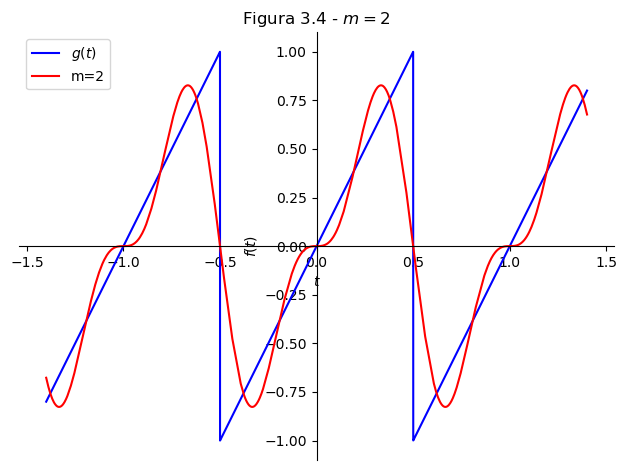

In [11]:
#from sympy import fourier_series
#from sympy.abc import t
g = sym.Piecewise((2*t, (-0.5 <= t) & (t <=0.5)), (0, True))
s = fourier_series(g, (t, -0.5, 0.5))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 20)
s5 = s.truncate(n = 5)

g = sym.Piecewise((2*t, (-0.5 <= t) & (t <=0.5)),
                  (2*(t - 1), (0.5 <= t) & (t <=1.5)), 
                  (2*(t + 1), (-1.5 <= t) & (t <=-0.5)))

p1 = sym.plot(g, s1, (t, -1.4, 1.4), title='Figura 3.4 - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -1.4, 1.4), title='Figura 3.4 - $m=20$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=20'

p1.show()

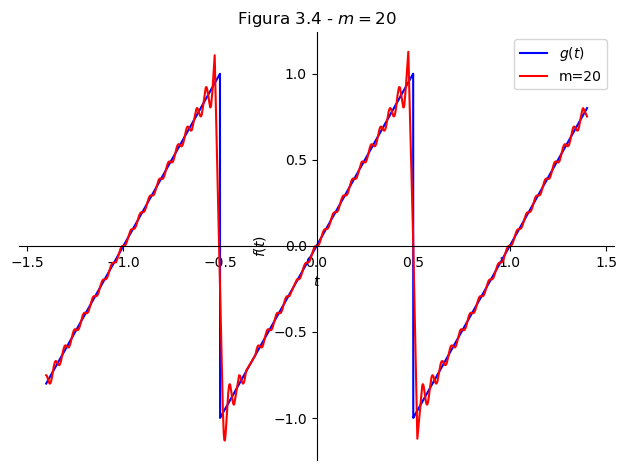

In [13]:
p2.show()

**Exemplo 3.5 (Fenômeno de Gibbs)** Os exemplos anteriores mostram um fenômeno, até certo ponto inesperado, que ocorre quando se faz o truncamento da série de Fourier. Era de se esperar que o truncamento $g_m(t)=\sum_{i=-m}^m \alpha_i e^{j \omega_i t}$ fornecesse aproximações mais precisas com o aumento de $m$. Isto ocorre em todos os pontos, salvo naqueles em que o sinal $g(t)$ não é contínuo. Neles, os exemplos sempre mostram que, com o aumentar de $m$, picos maiores aparecem. Estes picos têm valores limitados e têm duração temporal cada vez menor, de tal forma que o erro quadrático mínimo não é impactado.

**Exemplo 3.6 (Espectro)** Os gráficos do módulo e do argumento dos coeficientes $\alpha_i \in$ $\mathbb{C}$ em função das frequências $\omega_i$ para todo $i \in \mathbb{Z}$ (ou, de forma equivalente, em função de $i \in \mathbb{Z}$ ) definem os **espectros de módulo e de fase** do sinal periódico $g(t)$. 

Para o Exemplo 3.4 o espectro de módulo é o gráfico de $\left(a T_0\right) /(2 \pi i)$ e o espectro de fase é o gráfico de $(\pi / 2) \cos (\pi i)$, ambos em função de $\omega_i$ para todo $i \in \mathbb{Z}$.

A série de Fourier permite calcular o valor eficaz (ou a potência média) de um determinado sinal manipulando diretamente os seus coeficientes. Esta propriedade decorre do **Teorema de Parseval**, um resultado bastante conhecido que tem larga utilização no estudo de sinais e sistemas.

**Teorema 3.1 (Teorema de Parseval)**  Se $\alpha_i \in \mathbb{C}$ são os coeficientes da série de Fourier do sinal $g(t)$, então
$$
\|g\|_{e f}^2=\sum_{i=-\infty}^{\infty}\left|\alpha_i\right|^2
$$

**Prova:** A prova é feita de maneira direta pelo cálculo do valor eficaz do sinal e e pelo uso da relação $g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}, t \in \mathbb{R}$ cuja validade é assegurada pela série de Fourier. Neste sentido, temos
$$
\begin{aligned}
\|g\|_{e f}^2 & =\frac{1}{T_0} \int_0^{T_0} g(t) g(t)^* d t \\
& =\frac{1}{T_0} \sum_{i=-\infty}^{\infty} \sum_{n=-\infty}^{\infty} \alpha_i \alpha_n^* \int_0^{T_0} e^{j\left(\omega_i-\omega_n\right) t} d t \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \alpha_i^*
\end{aligned}
$$

A prova do Teorema de Parseval coloca em clara evidência que o seu resultado assenta-se na ortogonalidade dos sinais elementares adotados na série de Fourier.

Como cada elemento da soma em $\|g\|_{e f}^2=\sum_{i=-\infty}^{\infty}\left|\alpha_i\right|^2$ é não negativo e o resultado final é limitado para sinais de potência limitada, certamente ocorrerá $\lim _{|i| \rightarrow \infty}\left|\alpha_i\right|=0$. Ou seja, os termos subsequentes da série de Fourier tendem a perder importância para o cálculo do valor eficaz do sinal.

Existem algumas relações úteis entre os coeficientes da série de Fourier. Note, por exemplo que 

$$
\begin{aligned}
\alpha_i^* & =\frac{1}{T_0} \int_0^{T_0} g(t) e^{+j\omega_i t} d t \\
 & =\frac{1}{T_0} \int_0^{T_0} g(t) e^{-j\omega_{-i} t} d t \\
 & =\alpha_{-i}
\end{aligned}
$$

Portanto, os coeficientes situados em posições simétricas em relação à origem são complexos conjugados. 

Ademais, reescrevendo $\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t) e^{-j \omega_i t} d t$ na forma equivalente 
$$
\alpha_i=\frac{1}{T_0} \int_{-T_0 / 2}^{T_0 / 2} g(t)\left(\cos \left(\omega_i t\right)-j \operatorname{sen}\left(\omega_i t\right)\right) d t
$$

para todo $i \in \mathbb{Z}$, fica claro que, se o sinal for par, então $\operatorname{Im}\left(\alpha_i\right)=0 $ e, assim, todos os coeficientes são reais. Por outro lado, se o sinal for ímpar, então $\operatorname{Re}\left(\alpha_i\right)=0$ e, assim, todos os coeficientes são imaginários puros. Os dois casos foram ilustrados através dos Exemplos 3.2 e 3.4, respectivamente. Estas relações podem ser úteis para a verificação de cálculos realizados em situações específicas.

A série de Fourier é uma ferramenta bastante eficaz para se calcular a resposta de um sistema LIT causal, definido pelo operador linear $\mathcal{S}[\cdot]$, a um sinal de entrada genérico, mas periódico. 

O Exemplo 2.15 da unidade anterior estabelece que $\mathcal{S}\left[e^{j \omega_i t}\right]=\hat{h}\left(j \omega_i\right) e^{j \omega_i t} \operatorname{com}$
$$
\hat{h}\left(j \omega_i\right)=\int_0^{\infty} e^{-j \omega_i t} h(t) d t
$$

sendo $h(t)$ a resposta ao impulso do sistema em consideração. 

Desenvolvendo a entrada periódica $g(t)$ em série de Fourier, com $g(t)=\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}$, a resposta $y(t)$ correspondente a esta entrada é determinada através de
$$
\begin{aligned}
y(t) & =\mathcal{S}\left[\sum_{i=-\infty}^{\infty} \alpha_i e^{j \omega_i t}\right] \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \mathcal{S}\left[e^{j \omega_i t}\right] \\
& =\sum_{i=-\infty}^{\infty} \alpha_i \hat{h}\left(j \omega_i\right) e^{j \omega_i t}
\end{aligned}
$$

Portanto, se definirmos $\beta_i=\alpha_i \hat{h}\left(j \omega_i\right)$ para todo $i \in \mathbb{Z}$, podemos concluir que a resposta do sistema é um sinal periódico, com o mesmo período do sinal de entrada, sendo $\beta_i$ para todo $i \in \mathbb{Z}$ os coeficientes da sua série de Fourier. Este fato tem uma consequência interessante. A resposta a qualquer sinal com domínio real resulta em um sinal de saída real, o que implica em termos $\beta_{-i}=\beta_i^*$ sempre que $\alpha_{-i}=\alpha_i^*$ para todo $i \in \mathbb{Z}$. Levando em conta que $\omega_{-i}=-\omega_i$, estes cálculos levam à conclusão de que
$$
\hat{h}\left(-j \omega_i\right)=\hat{h}\left(j \omega_i\right)^*
$$

para todo $i \in \mathbb{Z}$. A resposta ao impulso de qualquer sistema LIT causal exibe esta propriedade. O exemplo dado a seguir ilustra a aplicação desses resultados.


**Exemplo 3.7** Um trem de pulsos como definido no Exemplo 3.2 passa por um sistema LIT causal (circuito RC) com resposta ao impulso dada no Exemplo 2.16, isto é, $h(t)=$ $e^{-t} v(t)$, que permite determinar com $\hat{h}\left(j \omega_i\right)=\int_0^{\infty} e^{-j \omega_i t} h(t) d t$ os coeficientes
$$
\beta_i=\frac{\alpha_i}{1+j \omega_i}
$$
da série de Fourier da resposta correspondente. Observe que $\beta_{-i}=\beta_i^*$ para todo $i \in \mathbb{Z}$ como esperado, pois o sinal de saída é real.